<a href="https://colab.research.google.com/github/laurelpilgrim-create/NYC-Airbnb-Analysis-/blob/main/Pilgrim_NYC_Airbnb_Insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

# Load the gzipped CSV file into a pandas DataFrame
df = pd.read_csv('/content/listings.csv.gz', compression='gzip')

# Display the first 5 rows of the DataFrame
display(df.head())

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20250105040826,2025-01-05,previous scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,...,4.56,3.22,3.67,NaN,f,1,1,0,0,0.07
1,3820211,https://www.airbnb.com/rooms/3820211,20250105040826,2025-01-05,city scrape,Restored Precinct in Center Sq. w/Parking,"Cozy, cool little 1BR Apt in the heart Albany'...","Great restaurants, architecture, walking, peop...",https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.81,4.82,4.78,NaN,f,4,4,0,0,2.42
2,5651579,https://www.airbnb.com/rooms/5651579,20250105040826,2025-01-05,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",The neighborhood is very eclectic. We have a v...,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,...,4.87,4.76,4.64,NaN,f,2,1,1,0,3.14
3,6623339,https://www.airbnb.com/rooms/6623339,20250105040826,2025-01-05,city scrape,Center Sq. Loft in Converted Precinct w/ Parking,Large renovated 1 bedroom apartment in convert...,"Located in Albany's finest urban neighborhood,...",https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.70,4.80,4.72,NaN,f,4,4,0,0,2.82
4,9005989,https://www.airbnb.com/rooms/9005989,20250105040826,2025-01-05,city scrape,"Studio in The heart of Center SQ, in Albany NY",(21 years of age or older ONLY) NON- SMOKING.....,"There are many shops, restaurants, bars, museu...",https://a0.muscache.com/pictures/d242a77e-437c...,17766924,...,4.93,4.87,4.78,NaN,f,1,1,0,0,5.90


In [5]:
# Display a summary of the DataFrame including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Data columns (total 75 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            429 non-null    int64  
 1   listing_url                                   429 non-null    object 
 2   scrape_id                                     429 non-null    int64  
 3   last_scraped                                  429 non-null    object 
 4   source                                        429 non-null    object 
 5   name                                          429 non-null    object 
 6   description                                   422 non-null    object 
 7   neighborhood_overview                         213 non-null    object 
 8   picture_url                                   429 non-null    object 
 9   host_id                                       429 non-null    int

In [9]:
# Clean the 'price' column: remove '$' and ',' and convert to numeric
df['price'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Impute missing 'price' values with the median
median_price = df['price'].median()
df['price'] = df['price'].fillna(median_price)

print(f"Missing values in 'price' after imputation: {df['price'].isnull().sum()}")

# Display descriptive statistics for the 'price' column to verify
display(df['price'].describe())

Missing values in 'price' after imputation: 0


,price
count,429.000000
mean,116.170163
std,93.594454
min,24.000000
25%,75.000000
50%,99.000000
75%,125.000000
max,1482.000000


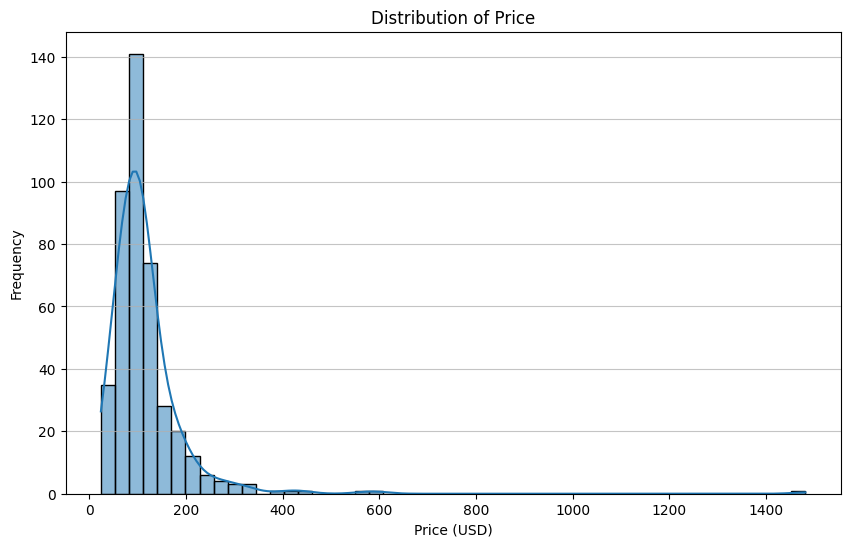

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of 'price' using a histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [11]:
# Check for duplicate records
duplicate_records = df.duplicated().sum()
print(f"Number of duplicate records found: {duplicate_records}")

# Remove duplicate records if any exist
if duplicate_records > 0:
    df.drop_duplicates(inplace=True)
    print(f"Removed {duplicate_records} duplicate records.")
    print(f"New shape of DataFrame after removing duplicates: {df.shape}")
else:
    print("No duplicate records found.")

Number of duplicate records found: 0
No duplicate records found.


In [12]:
# Group by 'neighbourhood_cleansed' and calculate the average price
average_price_by_neighborhood = df.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False)

# Display the top 5 neighborhoods with the highest average prices
display(average_price_by_neighborhood.head())

,price
neighbourhood_cleansed,
FIFTEENTH WARD,163.937500
FOURTEENTH WARD,160.750000
EIGHTH WARD,157.090909
FIRST WARD,141.555556
SECOND WARD,132.489796


In [13]:
# Calculate the average price for each room type
average_price_by_room_type = df.groupby('room_type')['price'].mean().sort_values(ascending=False)

print("Average price by room type:")
display(average_price_by_room_type)

Average price by room type:


,price
room_type,
Entire home/apt,131.756494
Private room,76.758333
Shared room,45.000000


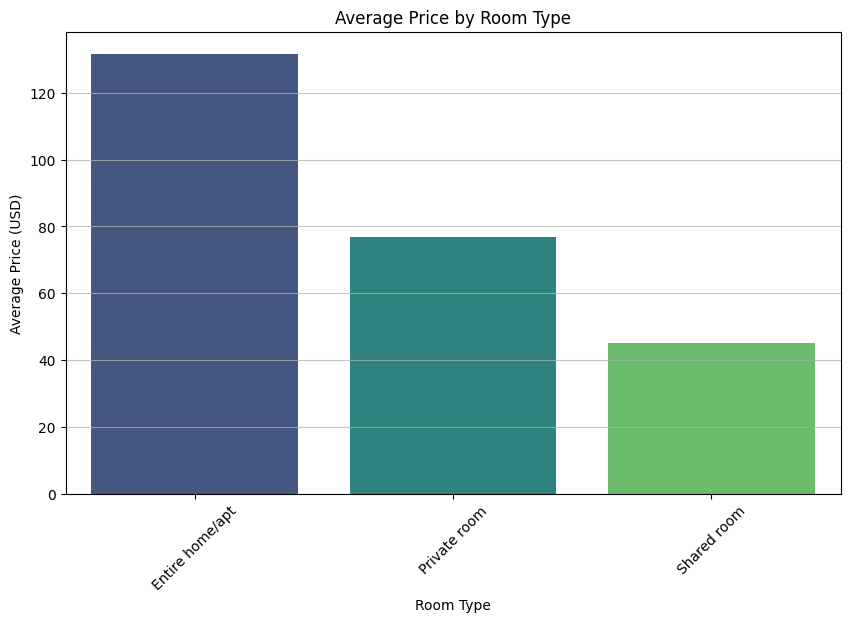

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the average price by room type
plt.figure(figsize=(10, 6))
sns.barplot(x=average_price_by_room_type.index, y=average_price_by_room_type.values, palette='viridis', hue=average_price_by_room_type.index, legend=False)
plt.title('Average Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.show()

### Map Visualization of Listings

To visualize the geographic distribution of listings, we'll create an interactive map using the `folium` library. Each listing will be represented by a marker at its corresponding latitude and longitude.

In [17]:
pip install folium

In [18]:
import folium

# Get the average latitude and longitude to center the map
center_lat = df['latitude'].mean()
center_lon = df['longitude'].mean()

# Create a Folium map centered at the average coordinates
m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

# Add markers for each listing
for idx, row in df.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"<b>Name:</b> {row['name']}<br><b>Price:</b> ${row['price']}<br><b>Room Type:</b> {row['room_type']}",
        tooltip=row['name']
    ).add_to(m)

# Display the map
display(m)

In [15]:
# Display descriptive statistics for 'price' grouped by 'room_type'
print("Descriptive statistics for price by room type:")
display(df.groupby('room_type')['price'].describe())

Descriptive statistics for price by room type:


,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,308.0,131.756494,103.965961,50.0,90.75,109.0,140.0,1482.0
Private room,120.0,76.758333,37.194017,24.0,54.25,62.0,97.5,200.0
Shared room,1.0,45.000000,NaN,45.0,45.00,45.0,45.0,45.0


### Impact of 'host_is_superhost' Status on Listing Prices

We will now investigate whether a host's 'superhost' status influences the price of their listings. We'll compare the average prices and distributions for listings associated with superhosts ('t') versus non-superhosts ('f').

In [19]:
# Calculate the average price for superhosts vs. non-superhosts
average_price_by_superhost = df.groupby('host_is_superhost')['price'].mean().sort_values(ascending=False)

print("Average price by Superhost status:")
display(average_price_by_superhost)

Average price by Superhost status:


,price
host_is_superhost,
t,123.991031
f,110.356021


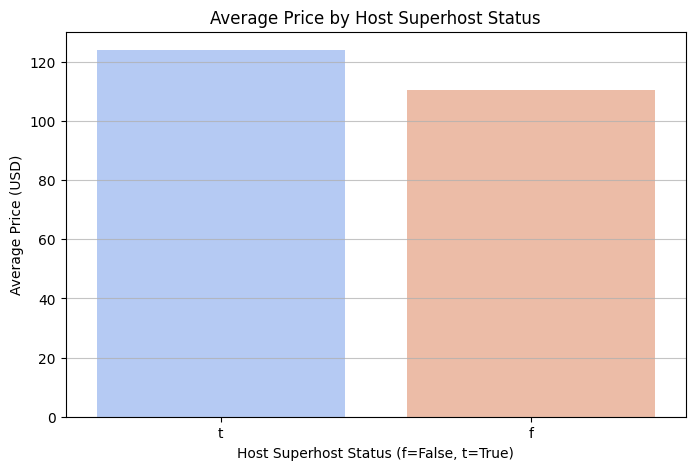

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the average price by superhost status
plt.figure(figsize=(8, 5))
sns.barplot(x=average_price_by_superhost.index, y=average_price_by_superhost.values, palette='coolwarm', hue=average_price_by_superhost.index, legend=False)
plt.title('Average Price by Host Superhost Status')
plt.xlabel('Host Superhost Status (f=False, t=True)')
plt.ylabel('Average Price (USD)')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [21]:
# Display descriptive statistics for 'price' grouped by 'host_is_superhost'
print("Descriptive statistics for price by Superhost status:")
display(df.groupby('host_is_superhost')['price'].describe())

Descriptive statistics for price by Superhost status:


,count,mean,std,min,25%,50%,75%,max
host_is_superhost,,,,,,,,
f,191.0,110.356021,56.638363,24.0,75.0,99.0,122.0,399.0
t,223.0,123.991031,117.893600,36.0,74.5,99.0,129.0,1482.0


### Descriptive Statistics for Numerical Columns

Let's compute key descriptive statistics (mean, median, range, variance, standard deviation) for all numerical columns in the DataFrame to get a comprehensive overview of their distributions and central tendencies.

In [22]:
import numpy as np

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Calculate mean, median, min, max, std, and variance
descriptive_stats = numeric_df.agg(['mean', 'median', 'min', 'max', 'std', 'var'])

# Calculate range separately as max - min
d_range = numeric_df.max() - numeric_df.min()
d_range.name = 'range'

# Combine all statistics into one DataFrame
all_stats = pd.concat([descriptive_stats, d_range.to_frame().T])

display(all_stats)

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
mean,6.691283e+17,2.025011e+13,2.367239e+08,29.067599,48.065268,42.657644,-73.776211,3.494172,1.202532,1.580189,...,4.792995,4.862112,4.870214,4.675508,4.729572,6.174825,4.379953,1.792541,0.002331,2.090936
median,8.038680e+17,2.025011e+13,1.923130e+08,4.000000,5.000000,42.656790,-73.772870,2.000000,1.000000,1.000000,...,4.880000,4.945000,4.960000,4.810000,4.830000,3.000000,2.000000,0.000000,0.000000,1.405000
min,2.992450e+06,2.025011e+13,6.576000e+04,1.000000,1.000000,42.630660,-73.876490,1.000000,0.000000,0.000000,...,3.000000,2.000000,3.000000,3.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.050000
max,1.325491e+18,2.025011e+13,6.671428e+08,1212.000000,2405.000000,42.714900,-73.738250,16.000000,7.000000,8.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,23.000000,23.000000,13.000000,1.000000,11.270000
std,4.945228e+17,0.000000e+00,1.909060e+08,149.370181,286.038942,0.009597,0.018662,2.566515,0.587081,1.110101,...,0.288217,0.278906,0.253123,0.367092,0.388818,6.409304,6.005657,3.636695,0.048280,2.079791
var,2.445528e+35,0.000000e+00,3.644510e+16,22311.451027,81818.276104,0.000092,0.000348,6.586999,0.344664,1.232325,...,0.083069,0.077788,0.064071,0.134757,0.151179,41.079178,36.067915,13.225552,0.002331,4.325529
range,1.325491e+18,0.000000e+00,6.670771e+08,1211.000000,2404.000000,0.084240,0.138240,15.000000,7.000000,8.000000,...,2.000000,3.000000,2.000000,2.000000,4.000000,22.000000,23.000000,13.000000,1.000000,11.220000


### Relationship between 'price' and 'accommodates'

Let's visualize the relationship between the listing's price and the number of people it accommodates using a scatter plot. This can help us understand if listings that accommodate more guests tend to be more expensive.

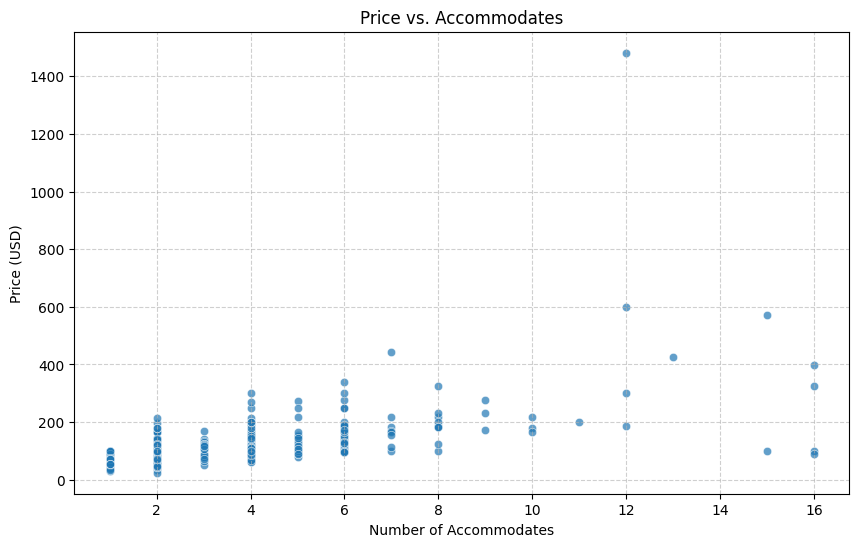

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='accommodates', y='price', data=df, alpha=0.7)
plt.title('Price vs. Accommodates')
plt.xlabel('Number of Accommodates')
plt.ylabel('Price (USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Relationship between 'price' and 'number_of_reviews'

Now, let's examine the relationship between the listing price and the number of reviews it has received using a scatter plot. This can help us understand if highly-reviewed listings tend to have different pricing strategies.

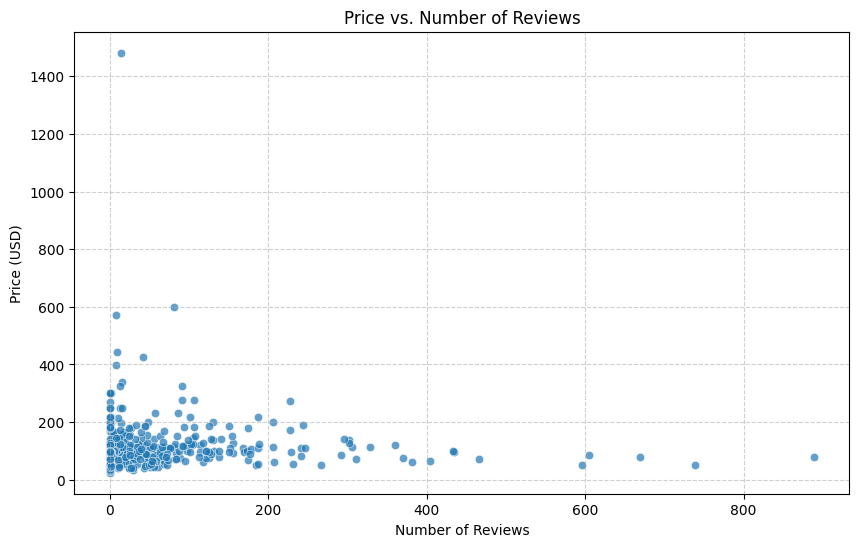

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='number_of_reviews', y='price', data=df, alpha=0.7)
plt.title('Price vs. Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Price (USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Average Price by Property Type

Next, we'll investigate how the 'property_type' influences the average listing price. We'll use a bar plot to visually compare the average prices across different property types.

Average price by property type:


,price
property_type,
Entire guesthouse,338.000000
Entire place,240.000000
Entire home,199.507937
Entire vacation home,186.500000
Room in hotel,146.818182
Entire townhouse,133.200000
Private room in bed and breakfast,125.333333
Entire condo,121.555556
Entire rental unit,110.246377


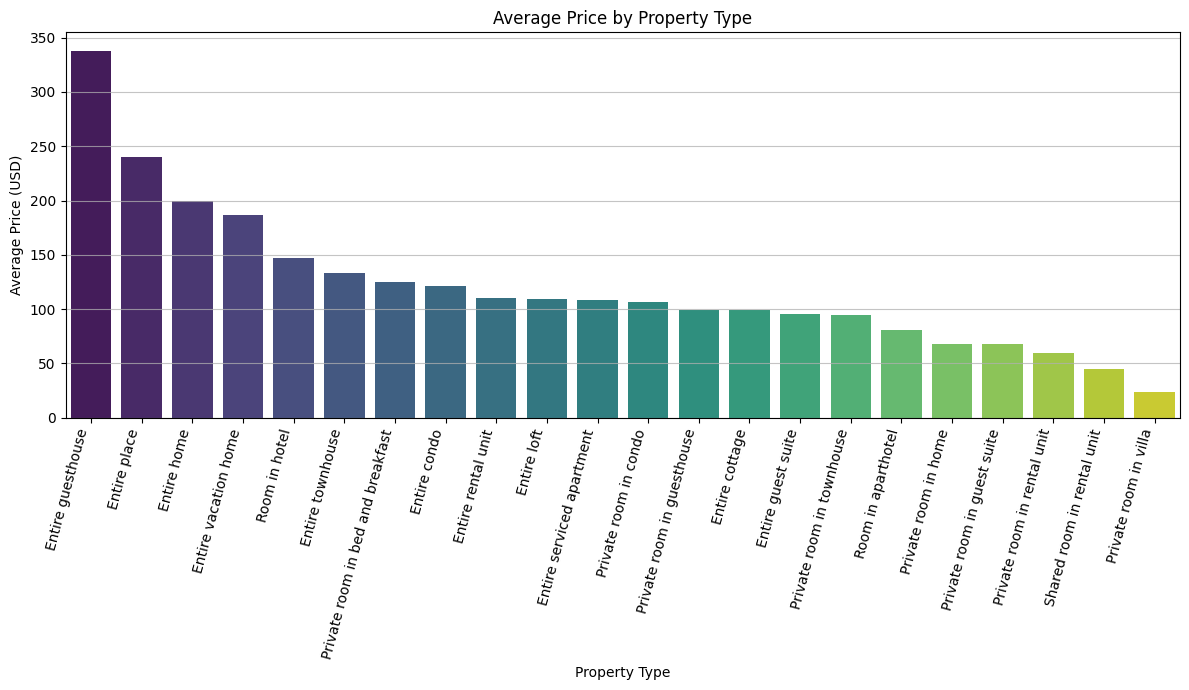

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average price for each property type
average_price_by_property_type = df.groupby('property_type')['price'].mean().sort_values(ascending=False)

print("Average price by property type:")
display(average_price_by_property_type)

# Visualize the average price by property type
plt.figure(figsize=(12, 7))
sns.barplot(x=average_price_by_property_type.index, y=average_price_by_property_type.values, palette='viridis', hue=average_price_by_property_type.index, legend=False)
plt.title('Average Price by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=75, ha='right') # Rotate labels for better readability
plt.grid(axis='y', alpha=0.75)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

### Average Price by Host Neighbourhood

Now, let's explore how the 'host_neighbourhood' impacts the average listing price. We'll group the data by this column, calculate the mean price, and visualize the results with a bar plot.

Average price by host neighbourhood:


,price
host_neighbourhood,
Whitehall,250.000000
Melrose,190.882353
Delaware Avenue,165.068966
Washington Park,151.285714
East Riverside - Oltorf,145.000000
Upper Washington Avenue,145.000000
Mansion Area,136.658537
Midtown East,135.000000
Helderberg,134.000000


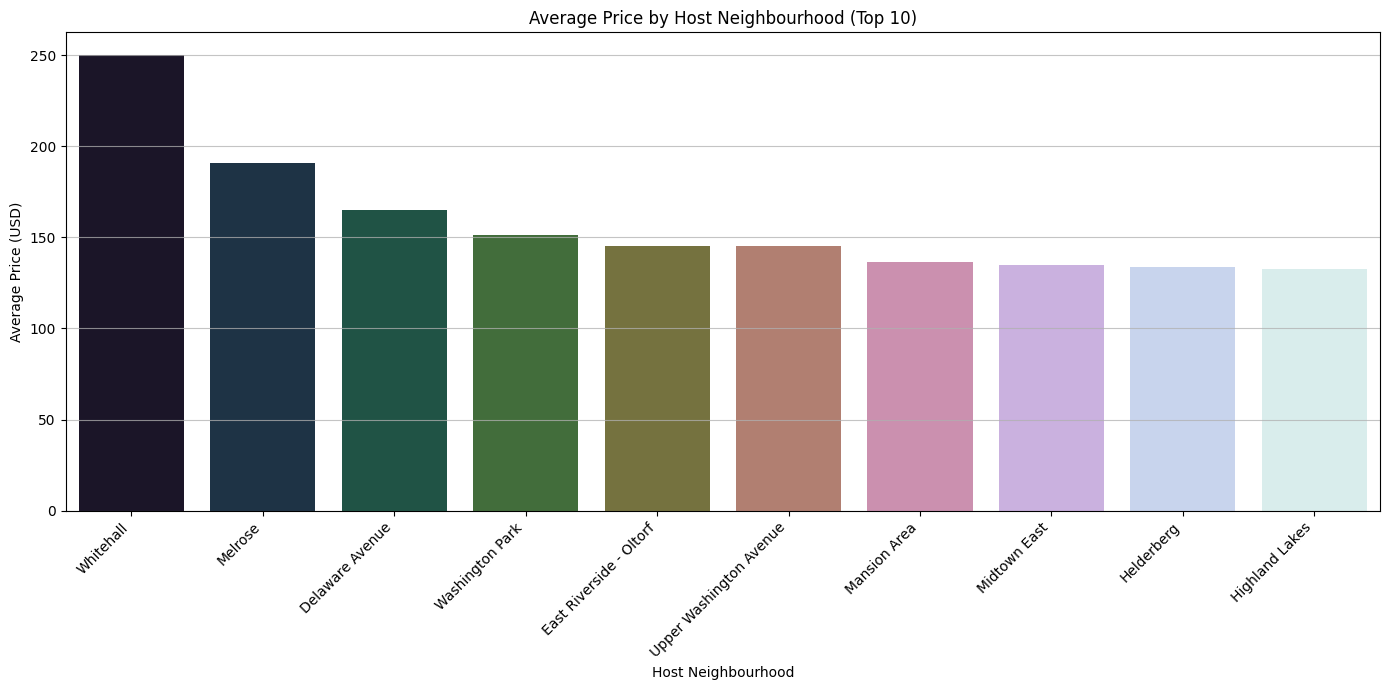

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average price for each host neighbourhood
average_price_by_host_neighbourhood = df.groupby('host_neighbourhood')['price'].mean().sort_values(ascending=False)

print("Average price by host neighbourhood:")
display(average_price_by_host_neighbourhood.head(10)) # Display top 10 for readability

# Visualize the average price by host neighbourhood
plt.figure(figsize=(14, 7))
sns.barplot(x=average_price_by_host_neighbourhood.index[:10], y=average_price_by_host_neighbourhood.values[:10], palette='cubehelix', hue=average_price_by_host_neighbourhood.index[:10], legend=False)
plt.title('Average Price by Host Neighbourhood (Top 10)')
plt.xlabel('Host Neighbourhood')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(axis='y', alpha=0.75)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

### Top 10 Most Expensive Listings

To identify the most luxurious or high-end listings, we will sort the DataFrame by 'price' in descending order and display the top 10 entries, focusing on their names and prices.

In [27]:
# Sort the DataFrame by 'price' in descending order and select the top 10
top_10_expensive_listings = df.sort_values(by='price', ascending=False).head(10)

print("Top 10 Most Expensive Listings:")
display(top_10_expensive_listings[['name', 'price']])

Top 10 Most Expensive Listings:


,name,price
150,One-of-a-Kind Luxe Urban Farmhouse w/ Heated Pool,1482.0
118,+ Perfect place to make memories with loved on...,600.0
26,/zBig Blue Ranch\ 1962 SUNY Eagle Hill 4Beds 2...,570.0
139,/Purple Potty Penthouse\ 1928 Pine Hill 4Bed 1...,444.0
94,"/ New Giant Victorian \ 7beds 6 baths + 2x 85""...",426.0
348,/A luxuryhome Near NYSCapital sleeps 10+W/D Gr...,399.0
266,Carriage House The Argus Hotel,338.0
308,Massive 5BD/4BA 3-Story Duplex @ Downtown Albany,325.0
226,Modern Cottage-Perfect for Families!,324.0
349,/An Oasis 8 ppl Yard Grill W/D\,301.0


### Map of Top 10 Most Expensive Listings

To visually pinpoint the locations of these high-value properties, I will create a new Folium map, specifically highlighting the top 10 most expensive listings. This will help us understand their geographical distribution.

In [28]:
import folium

# Get the average latitude and longitude of the top 10 listings to center the map
# Using existing center_lat, center_lon for overall context. Could also calculate specifically for top 10.
map_expensive_listings = folium.Map(location=[center_lat, center_lon], zoom_start=11)

# Add markers for each of the top 10 most expensive listings
for idx, row in top_10_expensive_listings.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"<b>Name:</b> {row['name']}<br><b>Price:</b> ${row['price']}<br><b>Room Type:</b> {row['room_type']}",
        tooltip=f"Expensive Listing: {row['name']}",
        icon=folium.Icon(color='red') # Use a distinct color for expensive listings
    ).add_to(map_expensive_listings)

# Display the map
display(map_expensive_listings)

### Comparison of Price and Number of Reviews for Top 10 Most Expensive Listings

To understand the relationship between price and popularity (as indicated by the number of reviews) for the most expensive listings, we'll visualize their prices and overlay the review counts.

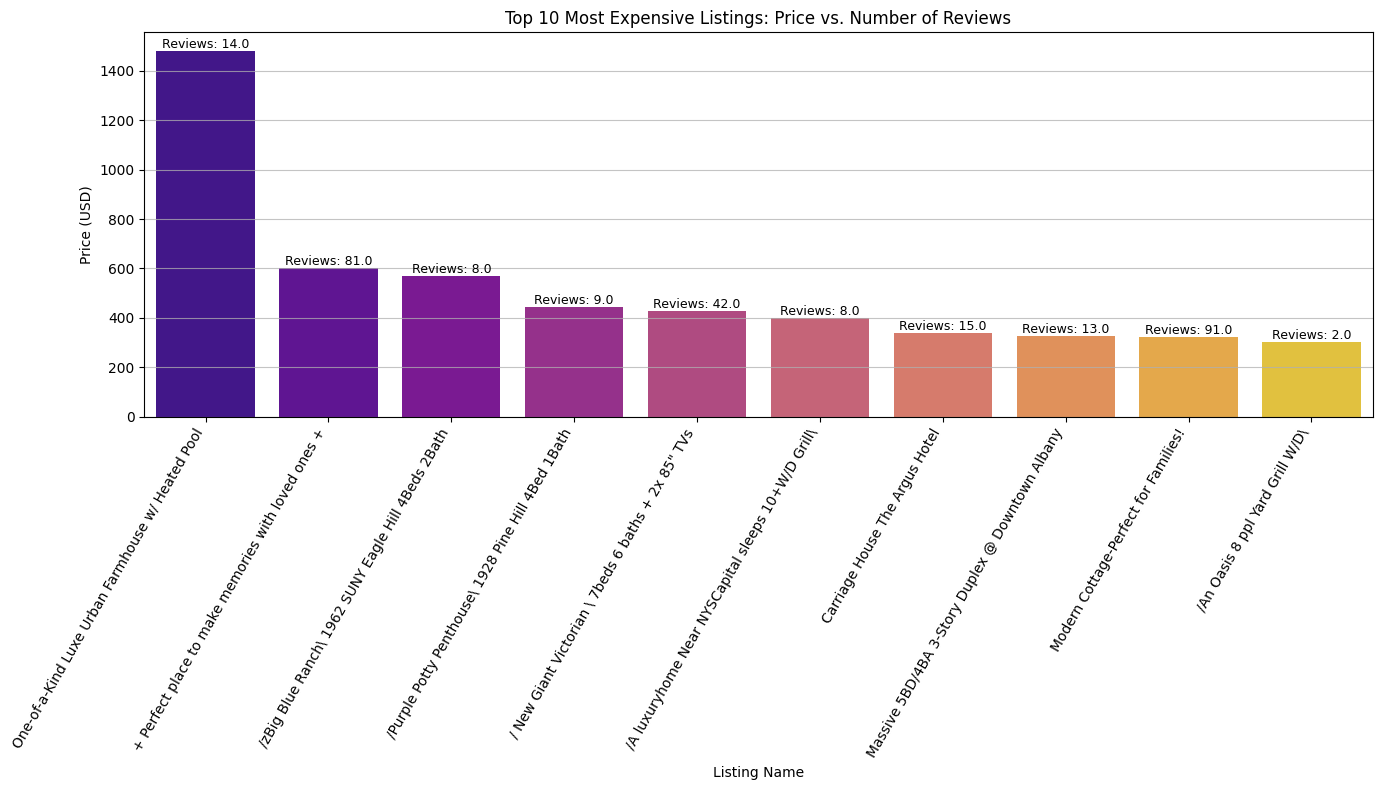

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for visualization
plot_data = top_10_expensive_listings[['name', 'price', 'number_of_reviews']].set_index('name')

plt.figure(figsize=(14, 8))
ax = sns.barplot(x=plot_data.index, y='price', data=plot_data, palette='plasma', hue=plot_data.index, legend=False)

plt.title('Top 10 Most Expensive Listings: Price vs. Number of Reviews')
plt.xlabel('Listing Name')
plt.ylabel('Price (USD)')
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', alpha=0.75)

# Annotate bars with the number of reviews
for index, row in plot_data.iterrows():
    ax.text(index, row['price'], f'Reviews: {row['number_of_reviews']}', color='black', ha="center", va='bottom', fontsize=9)

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

### Correlation between Price and Number of Reviews

Let's calculate the Pearson correlation coefficient between the 'price' and 'number_of_reviews' columns to quantify their linear relationship.

In [30]:
correlation = df['price'].corr(df['number_of_reviews'])
print(f"Correlation between Price and Number of Reviews: {correlation:.2f}")

Correlation between Price and Number of Reviews: -0.04


In [6]:
# Calculate the percentage of missing values for each column
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

# Filter to show only columns with missing values and sort them
missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
}).sort_values(by='Missing Percentage', ascending=False)

missing_info = missing_info[missing_info['Missing Count'] > 0]

display(missing_info)

,Missing Count,Missing Percentage
license,429,100.000000
calendar_updated,429,100.000000
neighbourhood_group_cleansed,429,100.000000
neighbourhood,216,50.349650
neighborhood_overview,216,50.349650
host_about,195,45.454545
host_location,86,20.046620
host_neighbourhood,66,15.384615
first_review,55,12.820513
review_scores_value,55,12.820513


In [7]:
# Get columns with 100% missing values
columns_to_drop = missing_info[missing_info['Missing Percentage'] == 100].index.tolist()

# Drop these columns from the DataFrame
df = df.drop(columns=columns_to_drop)

print(f"Dropped {len(columns_to_drop)} columns with 100% missing values: {columns_to_drop}")

# Verify that the columns are dropped by checking df.info() again or re-calculating missing values
df.info()

Dropped 3 columns with 100% missing values: ['license', 'calendar_updated', 'neighbourhood_group_cleansed']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Data columns (total 72 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            429 non-null    int64  
 1   listing_url                                   429 non-null    object 
 2   scrape_id                                     429 non-null    int64  
 3   last_scraped                                  429 non-null    object 
 4   source                                        429 non-null    object 
 5   name                                          429 non-null    object 
 6   description                                   422 non-null    object 
 7   neighborhood_overview                         213 non-null    object 
 8   picture_url                     